In [43]:
import polars as pl
import matplotlib.pyplot as plt

In [181]:
salary = pl.read_csv("Salary_dataset.csv")
df = pl.DataFrame(salary)
X = df['YearsExperience']
y = df['Salary']

In [182]:
def predict(X, theta):
  return theta[0] + theta[1] * X

In [187]:
def fit(X, y, theta, alpha, num_iters):
  m = X.shape[0]
  for i in range(num_iters):
    y_predict = predict(X, theta)
    dtheta0 = (1 / m) * ((y_predict - y).sum())
    dtheta1 = (1 / m) * (((y_predict - y) * X).sum())
    theta[0] -= alpha * dtheta0
    theta[1] -= alpha * dtheta1
  return theta

In [188]:
theta = pl.Series([0.0, 0.0])
finedtuned_theta = fit(X, y, theta, 0.01, 1000)
finedtuned_theta

""
f64
21912.589184
9880.814005


In [189]:
def visualize(theta, X, y):
  fig, ax = plt.subplots()
  ax.plot(X, y, "o")
  y_predict = predict(X, theta)
  ax.plot(X, y_predict, "-", color="C0")

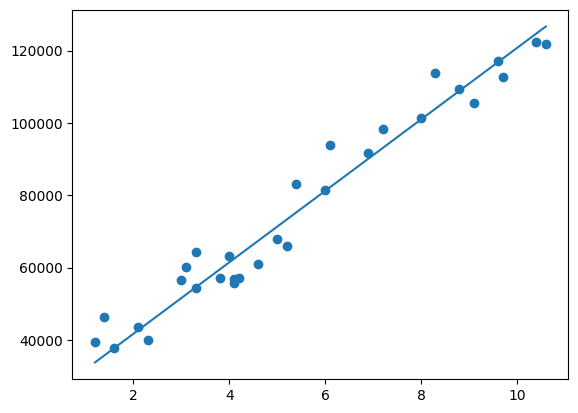

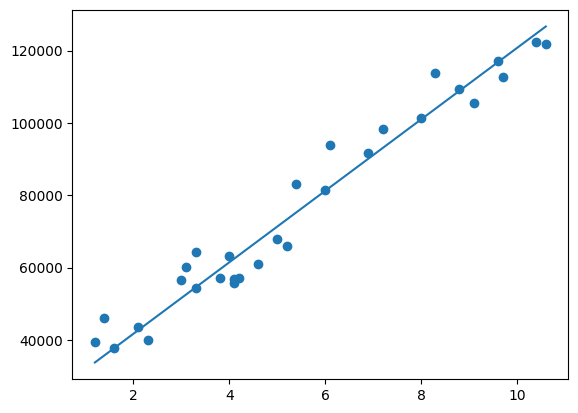

In [190]:
visualize(fit(X, y, theta, 0.01, 0), X, y)
visualize(fit(X, y, theta, 0.01, 2), X, y)
# visualize(fit(X, y, theta, 0.01, 3), X, y)
# visualize(fit(X, y, theta, 0.01, 4), X, y)
# visualize(fit(X, y, theta, 0.01, 1000), X, y)

In [193]:
X = pl.Series("X", [1, 2, 3, 4, 5])
y = pl.Series("y", [2, 4, 6, 8, 10])
theta = [0.0, 0.0]
alpha = 0.02
num_iters = 10000

theta = fit(X, y, theta, alpha, num_iters)
print(theta)  # should converge close to [0, 2]

[8.424360046094841e-15, 1.9999999999999973]
